In [48]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from SamplerExperimentFunctionJump import run_diagonal_walk_experimentJump

# Sampling and convergence scoring

### Convergence score
`convergence_score(counts_dict, n)` measures how close the empirical distribution after `n` samples is to the uniform target over all valid pairs with `x0 + x1 == 11`.  
It converts the cumulative counts into empirical probabilities and compares them to the uniform target distribution.  
The comparison uses total variation distance (TV).  
The score is normalized as `1 - TV / worst_TV`, so it lies between `0` and `1`.  
A value near `1` means the sampler is close to uniform over the valid states.  
A value near `0` means the samples are still highly concentrated on only a few states.
#### In math:

Let the valid states be

$$
\mathcal V=\{(x_0,x_1)\;:\;x_0+x_1=11\}
$$

and let $K=|\mathcal V|$. From the cumulative counts, the empirical distribution after $n$ samples is

$$
\hat p_n(v)=\frac{\mathrm{count}(v)}{n},
\qquad v\in\mathcal V
$$

The target distribution is uniform over valid states:

$$
p^{*}(v)=\frac{1}{K},
\qquad v\in\mathcal V
$$

The total variation distance is

$$
TV(\hat p_n,p^{*})
=
\frac12\sum_{v\in\mathcal V}\left|\hat p_n(v)-p^{*}(v)\right|
$$

and the convergence score is

$$
\mathrm{score}
=
1-\frac{TV(\hat p_n,p^{*})}{1-\frac1K}
$$

so the score lies in

$$
0 \le \mathrm{score} \le 1
$$

where values near $1$ mean close to uniform convergence.

In [49]:

DOMAIN = list(range(1, 11))
VALID_PAIRS = [(a, b) for a in DOMAIN for b in DOMAIN if a + b == 11]
K = len(VALID_PAIRS)

def convergence_score(counts_dict, n):
    empirical = np.array([counts_dict.get(p, 0) / n for p in VALID_PAIRS], dtype=float)
    target = np.full(K, 1.0 / K, dtype=float)

    tv = 0.5 * np.abs(empirical - target).sum()
    worst_tv = 1.0 - 1.0 / K
    return 1.0 - tv / worst_tv

### Sampling output format
`run_diagonal_walk_experiment(...)` returns a dictionary keyed by `D`.  
For each `D`, the value is another dictionary with:
`"trace_counts"`, `"samples"`, `"sample_times"`, `"avg_sample_time"`, and `"total_time"`.  
`trace_counts[i]` is the cumulative count dictionary after sample `i+1`, with keys `(x0, x1)` and values equal to how many times that valid pair has been seen so far.  
`samples` stores the raw sampled states in order as dictionaries like `{"x0": 4, "x1": 7}`.  
`sample_times[i]` is the time spent obtaining sample `i+1`.  
`avg_sample_time` is the mean of `sample_times`, and `total_time` is their sum.

### Structure:

```text
results
└── D
    ├── "trace_counts"          > list of length num_samples
    │   └── trace_counts[i]
    │       └── {(x0, x1): cumulative_count, ...}
    ├── "samples"               -> list of sampled states
    │   └── {"x0": int, "x1": int}
    ├── "sample_times"          -> list of per-sample times in seconds
    ├── "avg_sample_time"       -> float
    └── "total_time"            -> float

In [50]:
n_runs = 10
num_samples = 3000
Ds = list(range(1, 11))
Jump = 0.05

all_results = []
for run_idx in range(n_runs):
    res = run_diagonal_walk_experimentJump(
        num_samples=num_samples,
        D_values=Ds,
        seed=42 + run_idx,
        JUMP=Jump
    )
    all_results.append(res)



### Multi-run output format

```text
all_results
├── results[run_idx]                  -> one full experiment run
│   └── results[run_idx][D]           -> output for one value of D
│       ├── "trace_counts"            -> cumulative counts after each sample
│       ├── "samples"                 -> sampled states in order
│       ├── "sample_times"            -> time for each individual sample
│       ├── "avg_sample_time"         -> mean of sample_times
│       └── "total_time"              -> sum of sample_times

In [51]:



def burn_in_results(all_results, burn):


    burned_all_results = []

    for run in all_results:
        burned_run = {}

        for D, data in run.items():
            burned_samples = data["samples"][burn:]
            burned_sample_times = data["sample_times"][burn:]

            pair_counts = Counter()
            rebuilt_trace_counts = []

            for s in burned_samples:
                pair_counts[(s["x0"], s["x1"])] += 1
                rebuilt_trace_counts.append(dict(pair_counts))

            burned_run[D] = {
                "trace_counts": rebuilt_trace_counts,
                "samples": burned_samples,
                "sample_times": burned_sample_times,
                "avg_sample_time": np.mean(burned_sample_times) if burned_sample_times else 0.0,
                "total_time": np.sum(burned_sample_times) if burned_sample_times else 0.0,
            }

        burned_all_results.append(burned_run)

    return burned_all_results

#all_results = burn_in_results(all_results, burn)

# Convergence per sample

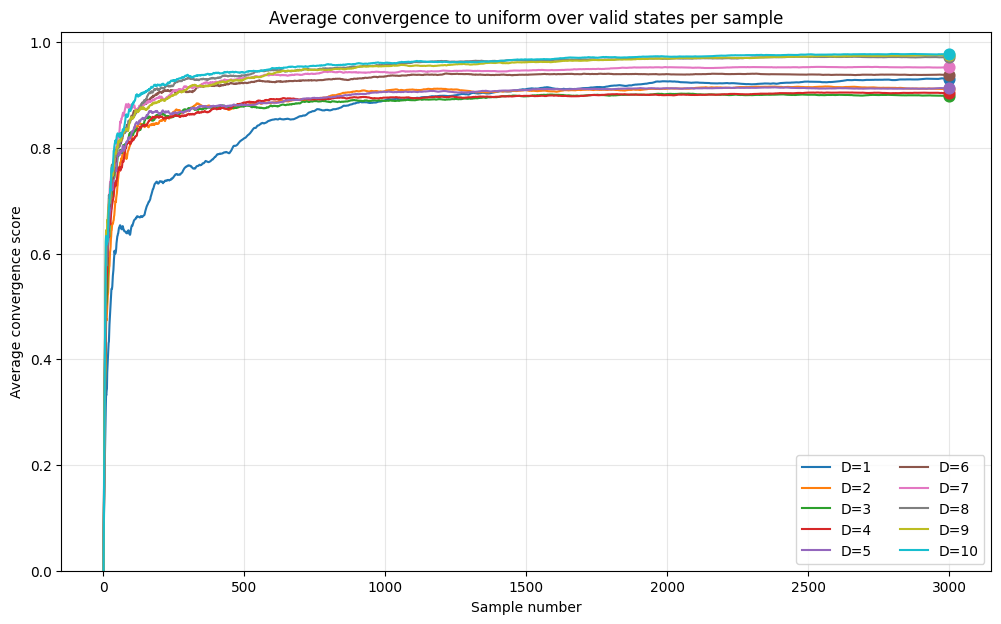

In [52]:
Ds = sorted(all_results[0].keys())

plt.figure(figsize=(12, 7))

for D in Ds:
    curves = []

    for run in all_results:
        data = run[D]
        y = [
            convergence_score(counts_dict, i)
            for i, counts_dict in enumerate(data["trace_counts"], start=1)
        ]
        curves.append(y)

    avg_y = np.mean(curves, axis=0)
    x = np.arange(1, len(avg_y) + 1)

    line, = plt.plot(x, avg_y, label=f"D={D}")
    plt.scatter([x[-1]], [avg_y[-1]], color=line.get_color(), s=60, zorder=3)

plt.xlabel("Sample number")
plt.ylabel("Average convergence score")
plt.title("Average convergence to uniform over valid states per sample")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

# Individual Sampling time per D

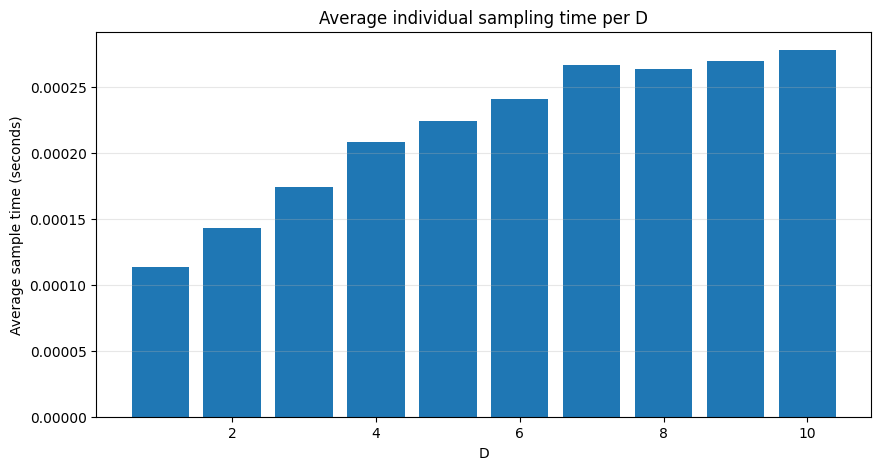

In [53]:
Ds = sorted(all_results[0].keys())

avg_sample_time_per_D = []
for D in Ds:
    times = [run[D]["avg_sample_time"] for run in all_results]
    avg_sample_time_per_D.append(np.mean(times))

plt.figure(figsize=(10, 5))
plt.bar(Ds, avg_sample_time_per_D)
plt.xlabel("D")
plt.ylabel("Average sample time (seconds)")
plt.title("Average individual sampling time per D")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# Total Time spent in sampling

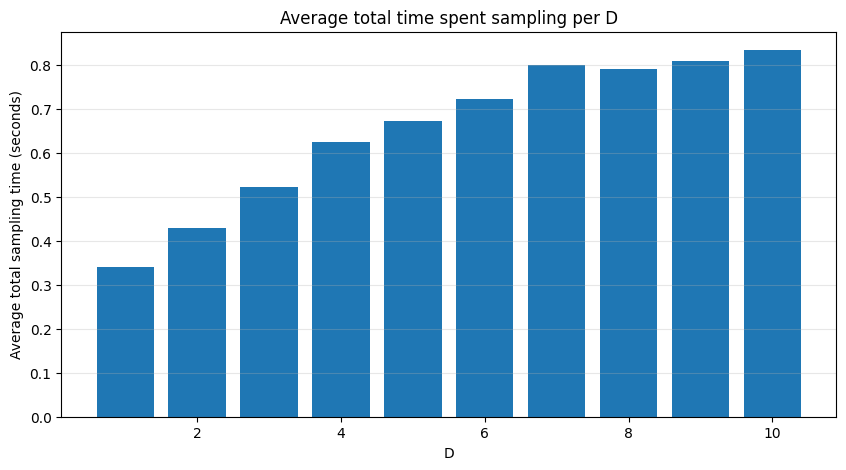

In [54]:
avg_total_times = [
    np.mean([res[D]["total_time"] for res in all_results])
    for D in Ds
]

plt.figure(figsize=(10, 5))
plt.bar(Ds, avg_total_times)
plt.xlabel("D")
plt.ylabel("Average total sampling time (seconds)")
plt.title("Average total time spent sampling per D")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# Convergnece per total Sampling time

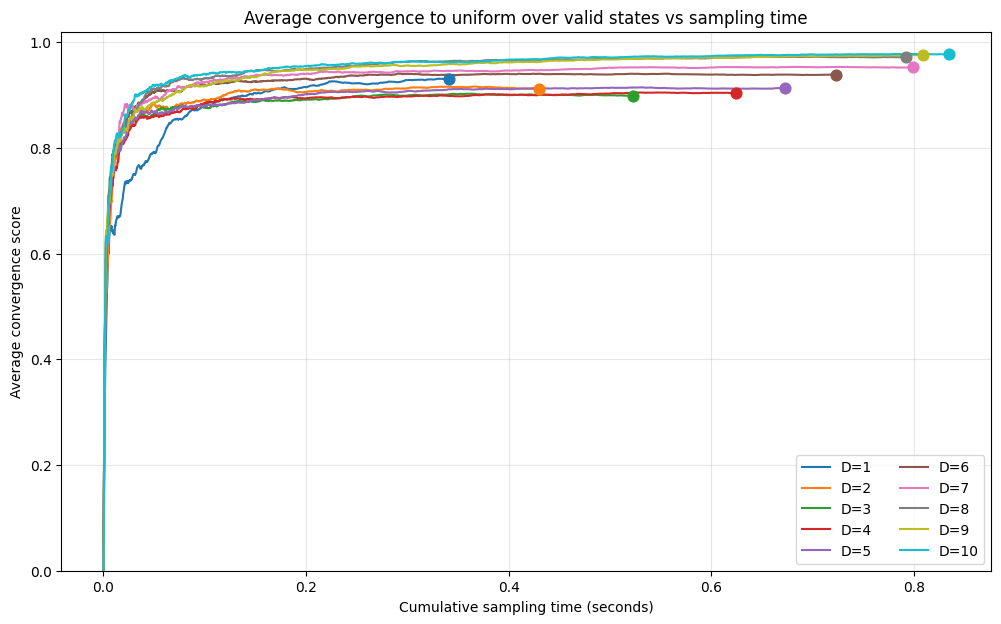

In [55]:
avg_curves = {}
avg_time_x = {}

for D in Ds:
    curves_for_D = []
    times_for_D = []

    for res in all_results:
        data = res[D]

        curve = [
            convergence_score(counts_dict, i)
            for i, counts_dict in enumerate(data["trace_counts"], start=1)
        ]
        curves_for_D.append(curve)
        times_for_D.append(np.cumsum(data["sample_times"]))

    avg_curves[D] = np.mean(curves_for_D, axis=0)
    avg_time_x[D] = np.mean(times_for_D, axis=0)

plt.figure(figsize=(12, 7))

for D in Ds:
    x = avg_time_x[D]
    y = avg_curves[D]

    line, = plt.plot(x, y, label=f"D={D}")
    plt.scatter([x[-1]], [y[-1]], color=line.get_color(), s=60, zorder=3)

plt.xlabel("Cumulative sampling time (seconds)")
plt.ylabel("Average convergence score")
plt.title("Average convergence to uniform over valid states vs sampling time")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

# Final convergence score

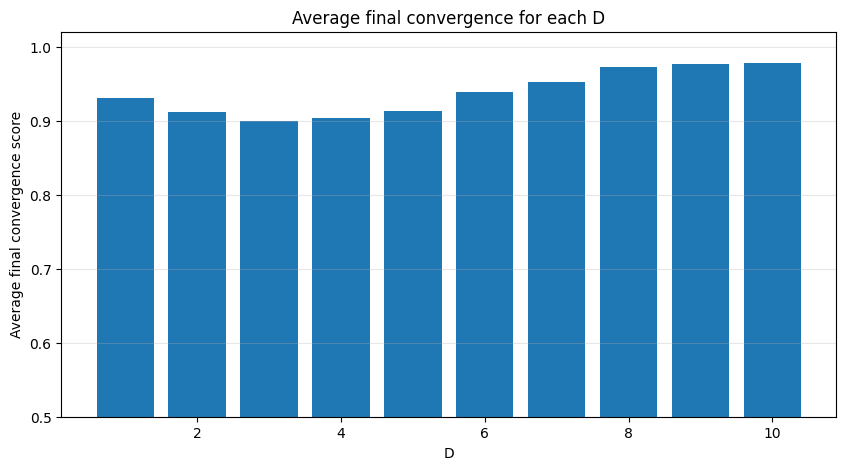

In [56]:
Ds = sorted(all_results[0].keys())

avg_final_convergence = []
for D in Ds:
    finals = []
    for run in all_results:
        data = run[D]
        n = len(data["trace_counts"])
        final_counts = data["trace_counts"][-1]
        finals.append(convergence_score(final_counts, n))
    avg_final_convergence.append(np.mean(finals))

plt.figure(figsize=(10, 5))
plt.bar(Ds, avg_final_convergence)
plt.xlabel("D")
plt.ylabel("Average final convergence score")
plt.title("Average final convergence for each D")
plt.ylim(0.5, 1.02)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [57]:
all_results[1][1]["Jumps"]

KeyError: 'Jumps'